In [1]:

import warnings
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import qnm

warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

G = 6.67430e-11
C = 299_792_458.0
MSUN = 1.988409870698051e30

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

baseline = np.load("pyring_gr_ringdown_templates.npz")

times = baseline["times"]
hp_pyring = baseline["kerrbh_hplus"]
hc_pyring = baseline["kerrbh_hcross"]

dt = times[1] - times[0]
fs = 1.0 / dt
duration = times[-1] + dt

print("Loaded GR baseline from pyRing.")
print("times shape:", times.shape)
print("baseline h_plus shape:", hp_pyring.shape)
print("duration:", duration)
print("sample rate:", fs)

@dataclass
class KerrRemnant:
    mass_msun: float
    chi: float

    def __post_init__(self):
        if self.mass_msun <= 0:
            raise ValueError("mass_msun must be positive")
        if not (-1.0 < self.chi < 1.0):
            raise ValueError("chi must satisfy -1 < chi < 1")

    @property
    def mass_si(self) -> float:
        return self.mass_msun * MSUN

    @property
    def time_unit(self) -> float:
        return G * self.mass_si / C**3


def get_kerr_qnm(remnant: KerrRemnant, l: int, m: int, n: int, s: int = -2) -> dict:
    mode_seq = qnm.modes_cache(s=s, l=l, m=m, n=n)
    omega = mode_seq(a=remnant.chi)[0]

    omega_r_geom = float(np.real(omega))
    omega_i_geom = float(-np.imag(omega))

    M_sec = remnant.time_unit
    omega_r_si = omega_r_geom / M_sec
    omega_i_si = omega_i_geom / M_sec

    return {
        "l": l,
        "m": m,
        "n": n,
        "omega_complex_geom": omega,
        "omega_r_geom": omega_r_geom,
        "omega_i_geom": omega_i_geom,
        "omega_r_si": omega_r_si,
        "omega_i_si": omega_i_si,
        "f_hz": omega_r_si / (2.0 * np.pi),
        "tau_s": 1.0 / omega_i_si,
    }


@dataclass
class RingdownMode:
    l: int
    m: int
    n: int
    amplitude: float
    phase: float


@dataclass
class ScalarLedMode:
    """
    Extra scalar-led damped mode for scalar-tensor / EsGB-like models.

    Here we parameterize directly in physical units because many papers
    discuss scalar-sector frequencies separately from the GR tensor
    Kerr sequence.
    """
    label: str
    amplitude: float
    phase: float
    f_hz: float
    tau_s: float


@dataclass
class RingdownSignal:
    t: np.ndarray
    h_complex: np.ndarray

    @property
    def h_plus(self) -> np.ndarray:
        return np.real(self.h_complex)

    @property
    def h_cross(self) -> np.ndarray:
        return -np.imag(self.h_complex)


@dataclass
class dCSParameters:
    """
    Parameters for a dCS-inspired tensor ringdown model.

    coupling : dimensionless bookkeeping parameter controlling the size
               of the dCS correction in the template.

    mode_shifts : optional explicit per-mode shifts, to be filled later
                  from paper-based fits or tables.
                  Example:
                      {
                          (2,2,0): {"d_omega_frac": ..., "d_tau_frac": ...},
                          (3,3,0): {"d_omega_frac": ..., "d_tau_frac": ...},
                      }
    """
    coupling: float = 0.0
    mode_shifts: dict | None = None


@dataclass
class ScalarTensorParameters:
    """
    Parameters for a scalar-tensor / Horndeski-like ringdown model.

    tensor_mode_shifts:
        optional deformations of the tensor Kerr-like sector

    scalar_modes:
        optional extra scalar-led damped modes

    scalar_to_tensor_projection:
        an overall factor for how strongly the scalar-led sector projects
        into the observed effective strain in this simplified model
    """
    tensor_mode_shifts: dict | None = None
    scalar_modes: list | None = None
    scalar_to_tensor_projection: float = 1.0


def component_strain_from_freqs(
    amplitude: float,
    phase: float,
    omega_r_si: float,
    omega_i_si: float,
    t: np.ndarray,
    t0: float = 0.0,
) -> np.ndarray:
    dt_local = t - t0
    mask = dt_local >= 0.0

    h = np.zeros_like(t, dtype=np.complex128)
    h[mask] = (
        amplitude
        * np.exp(-omega_i_si * dt_local[mask])
        * np.exp(-1j * (omega_r_si * dt_local[mask] + phase))
    )
    return h


def scalar_led_component(
    amplitude: float,
    phase: float,
    f_hz: float,
    tau_s: float,
    t: np.ndarray,
    t0: float = 0.0,
) -> np.ndarray:
    """
    Build a scalar-led damped sinusoid in the same complex bookkeeping form.

    This is a phenomenological projection into an effective observed strain.
    We are not yet building a detector-specific scalar polarization response.
    """
    omega_r_si = 2.0 * np.pi * f_hz
    omega_i_si = 1.0 / tau_s
    return component_strain_from_freqs(
        amplitude=amplitude,
        phase=phase,
        omega_r_si=omega_r_si,
        omega_i_si=omega_i_si,
        t=t,
        t0=t0,
    )


def generate_gr_ringdown(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    t: np.ndarray,
    t0: float = 0.0,
    s: int = -2,
) -> RingdownSignal:
    h = np.zeros_like(t, dtype=np.complex128)

    for mode in modes:
        q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)
        h += component_strain_from_freqs(
            amplitude=mode.amplitude,
            phase=mode.phase,
            omega_r_si=q["omega_r_si"],
            omega_i_si=q["omega_i_si"],
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)


def generate_dcs_ringdown(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    dcs_params: dCSParameters,
    t: np.ndarray,
    t0: float = 0.0,
    s: int = -2,
) -> RingdownSignal:
    h = np.zeros_like(t, dtype=np.complex128)
    shift_dict = dcs_params.mode_shifts or {}

    for mode in modes:
        q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)

        shift = shift_dict.get((mode.l, mode.m, mode.n), {})
        d_omega_frac = dcs_params.coupling * shift.get("d_omega_frac", 0.0)
        d_tau_frac = dcs_params.coupling * shift.get("d_tau_frac", 0.0)
        d_amp_frac = dcs_params.coupling * shift.get("d_amp_frac", 0.0)
        d_phase = dcs_params.coupling * shift.get("d_phase", 0.0)

        if 1.0 + d_tau_frac <= 0.0:
            raise ValueError("Invalid dCS damping deformation: 1 + d_tau_frac must be > 0")

        omega_r_new = q["omega_r_si"] * (1.0 + d_omega_frac)
        omega_i_new = q["omega_i_si"] / (1.0 + d_tau_frac)
        amp_new = mode.amplitude * (1.0 + d_amp_frac)
        phase_new = mode.phase + d_phase

        h += component_strain_from_freqs(
            amplitude=amp_new,
            phase=phase_new,
            omega_r_si=omega_r_new,
            omega_i_si=omega_i_new,
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)


def generate_scalar_tensor_ringdown(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    st_params: ScalarTensorParameters,
    t: np.ndarray,
    t0: float = 0.0,
    s: int = -2,
) -> RingdownSignal:
    h = np.zeros_like(t, dtype=np.complex128)

    tensor_shifts = st_params.tensor_mode_shifts or {}
    scalar_modes = st_params.scalar_modes or []

    for mode in modes:
        q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)

        shift = tensor_shifts.get((mode.l, mode.m, mode.n), {})
        d_omega_frac = shift.get("d_omega_frac", 0.0)
        d_tau_frac = shift.get("d_tau_frac", 0.0)
        d_amp_frac = shift.get("d_amp_frac", 0.0)
        d_phase = shift.get("d_phase", 0.0)

        if 1.0 + d_tau_frac <= 0.0:
            raise ValueError("Invalid scalar-tensor tensor-sector damping deformation")

        omega_r_new = q["omega_r_si"] * (1.0 + d_omega_frac)
        omega_i_new = q["omega_i_si"] / (1.0 + d_tau_frac)
        amp_new = mode.amplitude * (1.0 + d_amp_frac)
        phase_new = mode.phase + d_phase

        h += component_strain_from_freqs(
            amplitude=amp_new,
            phase=phase_new,
            omega_r_si=omega_r_new,
            omega_i_si=omega_i_new,
            t=t,
            t0=t0,
        )

    for sm in scalar_modes:
        h += st_params.scalar_to_tensor_projection * scalar_led_component(
            amplitude=sm.amplitude,
            phase=sm.phase,
            f_hz=sm.f_hz,
            tau_s=sm.tau_s,
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)


remnant = KerrRemnant(mass_msun=60.0, chi=0.7)
t0 = 0.002

modes = [
    RingdownMode(l=2, m=2, n=0, amplitude=1.00, phase=0.00),
    RingdownMode(l=2, m=2, n=1, amplitude=0.45, phase=0.30),
    RingdownMode(l=3, m=3, n=0, amplitude=0.25, phase=-0.50),
]

signal_gr = generate_gr_ringdown(remnant, modes, times, t0=t0)

print("Block 1 setup complete.")
print("Explicit GR waveform max |h|:", np.max(np.abs(signal_gr.h_complex)))
print("Loaded pyRing baseline max |h_plus|:", np.max(np.abs(hp_pyring)))

/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:163: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle)
/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:169: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle, encoding='latin1')


Loaded GR baseline from pyRing.
times shape: (410,)
baseline h_plus shape: (410,)
duration: 0.050048828125
sample rate: 8192.0
Block 1 setup complete.
Explicit GR waveform max |h|: 1.6076149728512328
Loaded pyRing baseline max |h_plus|: 5.921592369048793e-21



Explicit GR template
--------------------
samples: 410
max |h|: 1.6076149728512328
max |h_plus|: 1.589487061809098
max |h_cross|: 1.242751112080918

dCS-inspired template
---------------------
samples: 410
max |h|: 1.6117677842543214
max |h_plus|: 1.5940170347127864
max |h_cross|: 1.2653192439322216

Scalar-tensor-inspired template
-------------------------------
samples: 410
max |h|: 1.7244473457488225
max |h_plus|: 1.7045303380408101
max |h_cross|: 1.3565018219298144


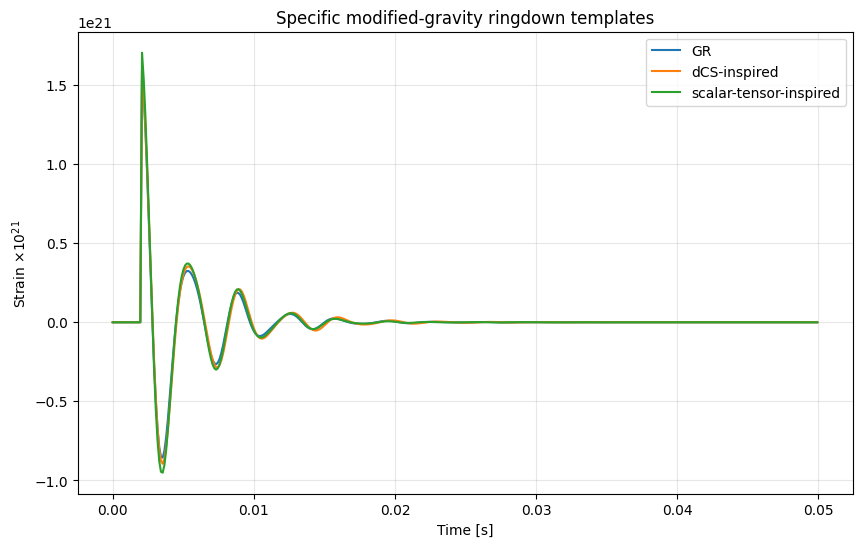

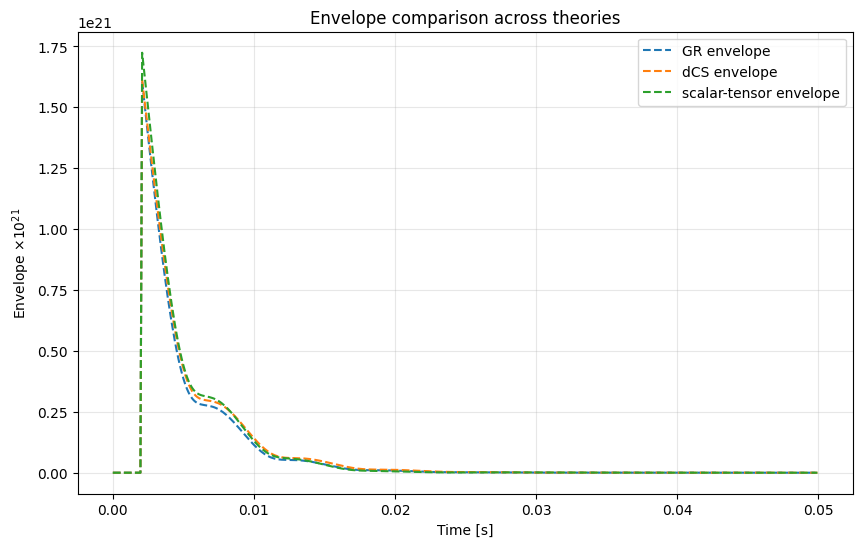

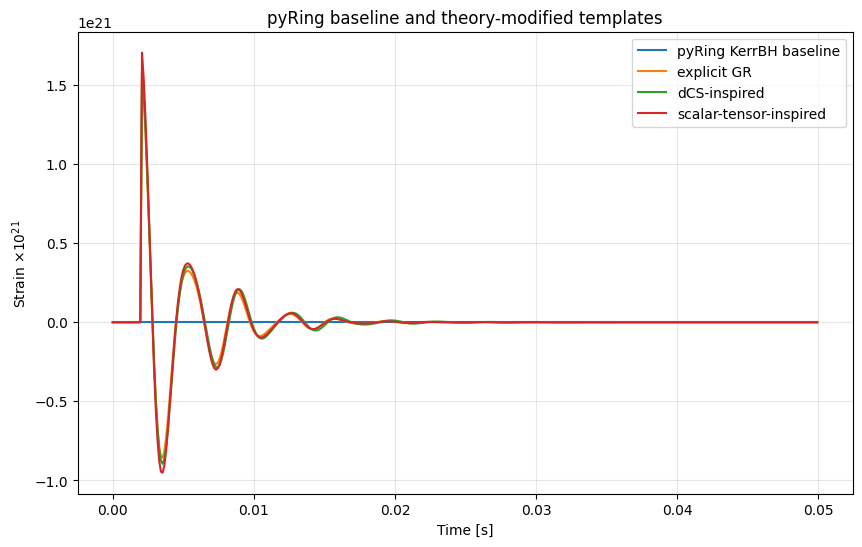


Tensor-mode summary (GR -> dCS-inspired)
----------------------------------------
mode (2,2,0): f_GR=286.83 Hz, tau_GR=3.658 ms -> f_dCS=282.53 Hz, tau_dCS=3.950 ms
mode (2,2,1): f_GR=280.67 Hz, tau_GR=1.210 ms -> f_dCS=277.86 Hz, tau_dCS=1.355 ms
mode (3,3,0): f_GR=454.36 Hz, tau_GR=3.567 ms -> f_dCS=445.27 Hz, tau_dCS=3.781 ms

Scalar-led mode summary (scalar-tensor-inspired)
------------------------------------------------
scalar_0: amplitude=0.080, phase=0.200, f=260.00 Hz, tau=6.000 ms
scalar_1: amplitude=0.040, phase=-0.350, f=420.00 Hz, tau=3.000 ms


In [2]:

def summarize_signal(name: str, sig: RingdownSignal):
    env = np.abs(sig.h_complex)
    print(f"\n{name}")
    print("-" * len(name))
    print("samples:", len(sig.t))
    print("max |h|:", np.max(env))
    print("max |h_plus|:", np.max(np.abs(sig.h_plus)))
    print("max |h_cross|:", np.max(np.abs(sig.h_cross)))


dcs_mode_shift_prototype = {
    (2, 2, 0): {
        "d_omega_frac": -0.015,
        "d_tau_frac":    0.080,
        "d_amp_frac":    0.000,
        "d_phase":       0.000,
    },

    (2, 2, 1): {
        "d_omega_frac": -0.010,
        "d_tau_frac":    0.120,
        "d_amp_frac":    0.000,
        "d_phase":       0.000,
    },

    (3, 3, 0): {
        "d_omega_frac": -0.020,
        "d_tau_frac":    0.060,
        "d_amp_frac":    0.000,
        "d_phase":       0.000,
    },
}

dcs_params = dCSParameters(
    coupling=1.0,
    mode_shifts=dcs_mode_shift_prototype,
)


scalar_tensor_tensor_shifts = {
    (2, 2, 0): {
        "d_omega_frac": 0.005,
        "d_tau_frac":   0.030,
        "d_amp_frac":   0.000,
        "d_phase":      0.000,
    },
    (2, 2, 1): {
        "d_omega_frac": 0.003,
        "d_tau_frac":   0.050,
        "d_amp_frac":   0.000,
        "d_phase":      0.000,
    },
}

scalar_led_modes = [
    ScalarLedMode(
        label="scalar_0",
        amplitude=0.08,
        phase=0.20,
        f_hz=260.0,
        tau_s=0.006,
    ),
    ScalarLedMode(
        label="scalar_1",
        amplitude=0.04,
        phase=-0.35,
        f_hz=420.0,
        tau_s=0.003,
    ),
]

st_params = ScalarTensorParameters(
    tensor_mode_shifts=scalar_tensor_tensor_shifts,
    scalar_modes=scalar_led_modes,
    scalar_to_tensor_projection=1.0,
)


signal_gr = generate_gr_ringdown(
    remnant=remnant,
    modes=modes,
    t=times,
    t0=t0,
)

signal_dcs = generate_dcs_ringdown(
    remnant=remnant,
    modes=modes,
    dcs_params=dcs_params,
    t=times,
    t0=t0,
)

signal_st = generate_scalar_tensor_ringdown(
    remnant=remnant,
    modes=modes,
    st_params=st_params,
    t=times,
    t0=t0,
)

summarize_signal("Explicit GR template", signal_gr)
summarize_signal("dCS-inspired template", signal_dcs)
summarize_signal("Scalar-tensor-inspired template", signal_st)


scale = 1e21

plt.figure()
plt.plot(times, scale * signal_gr.h_plus, label="GR")
plt.plot(times, scale * signal_dcs.h_plus, label="dCS-inspired")
plt.plot(times, scale * signal_st.h_plus, label="scalar-tensor-inspired")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("Specific modified-gravity ringdown templates")
plt.legend()
plt.show()


plt.figure()
plt.plot(times, scale * np.abs(signal_gr.h_complex), "--", label="GR envelope")
plt.plot(times, scale * np.abs(signal_dcs.h_complex), "--", label="dCS envelope")
plt.plot(times, scale * np.abs(signal_st.h_complex), "--", label="scalar-tensor envelope")
plt.xlabel("Time [s]")
plt.ylabel(r"Envelope $\times 10^{21}$")
plt.title("Envelope comparison across theories")
plt.legend()
plt.show()


plt.figure()
plt.plot(times, scale * hp_pyring, label="pyRing KerrBH baseline")
plt.plot(times, scale * signal_gr.h_plus, label="explicit GR")
plt.plot(times, scale * signal_dcs.h_plus, label="dCS-inspired")
plt.plot(times, scale * signal_st.h_plus, label="scalar-tensor-inspired")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("pyRing baseline and theory-modified templates")
plt.legend()
plt.show()


print("\nTensor-mode summary (GR -> dCS-inspired)")
print("----------------------------------------")

for mode in modes:
    q_gr = get_kerr_qnm(remnant, mode.l, mode.m, mode.n)
    shift = dcs_mode_shift_prototype.get((mode.l, mode.m, mode.n), {})
    d_omega_frac = dcs_params.coupling * shift.get("d_omega_frac", 0.0)
    d_tau_frac = dcs_params.coupling * shift.get("d_tau_frac", 0.0)

    f_gr = q_gr["f_hz"]
    tau_gr = q_gr["tau_s"]

    f_dcs = f_gr * (1.0 + d_omega_frac)
    tau_dcs = tau_gr * (1.0 + d_tau_frac)

    print(
        f"mode ({mode.l},{mode.m},{mode.n}): "
        f"f_GR={f_gr:.2f} Hz, tau_GR={1e3*tau_gr:.3f} ms -> "
        f"f_dCS={f_dcs:.2f} Hz, tau_dCS={1e3*tau_dcs:.3f} ms"
    )


print("\nScalar-led mode summary (scalar-tensor-inspired)")
print("------------------------------------------------")
for sm in scalar_led_modes:
    print(
        f"{sm.label}: amplitude={sm.amplitude:.3f}, "
        f"phase={sm.phase:.3f}, "
        f"f={sm.f_hz:.2f} Hz, "
        f"tau={1e3*sm.tau_s:.3f} ms"
    )

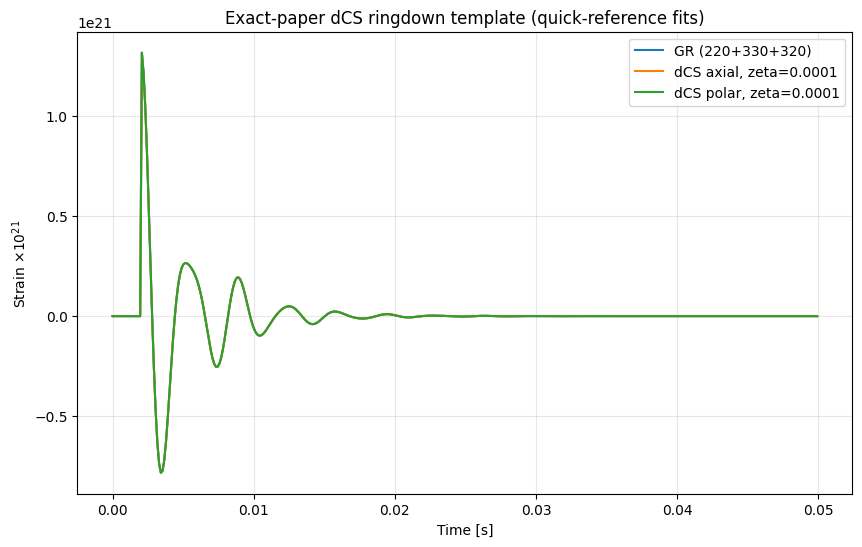

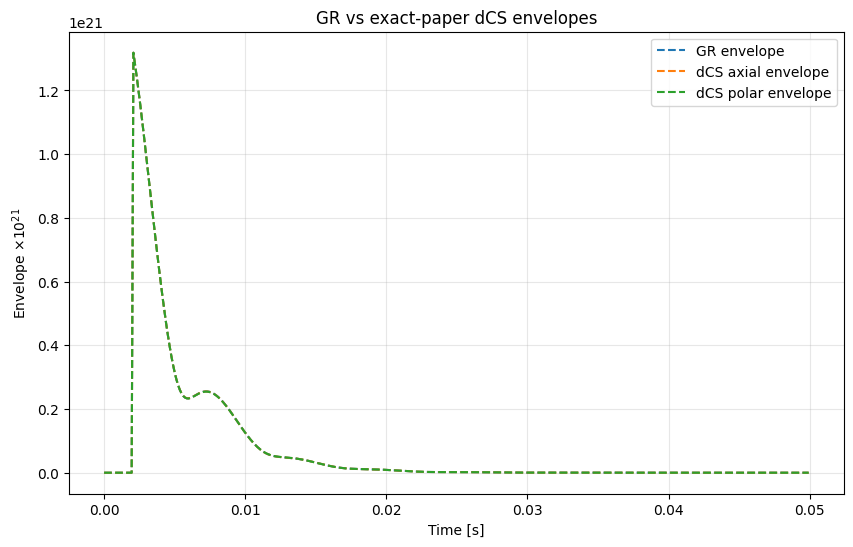


Exact-paper dCS summary using zeta = 0.0001
--------------------------------------------------

Parity: axial
mode (2,2,0): f_GR=286.827 Hz, tau_GR=3.6579 ms | f_dCS=286.665 Hz, tau_dCS=3.6581 ms
mode (3,3,0): f_GR=454.361 Hz, tau_GR=3.5668 ms | f_dCS=454.065 Hz, tau_dCS=3.5662 ms
mode (3,2,0): f_GR=408.847 Hz, tau_GR=3.5103 ms | f_dCS=408.365 Hz, tau_dCS=3.4732 ms

Parity: polar
mode (2,2,0): f_GR=286.827 Hz, tau_GR=3.6579 ms | f_dCS=286.748 Hz, tau_dCS=3.6572 ms
mode (3,3,0): f_GR=454.361 Hz, tau_GR=3.5668 ms | f_dCS=454.277 Hz, tau_dCS=3.5656 ms
mode (3,2,0): f_GR=408.847 Hz, tau_GR=3.5103 ms | f_dCS=407.861 Hz, tau_dCS=3.5063 ms


In [3]:


DCS_QUICKREF_COEFFS = {
    "axial": {
        (2, 2, 0): [
            complex(-0.246041, -0.125482),
            complex(-0.35908,  -0.184144),
            complex(-0.595672,  0.0876598),
            complex( 1.41373,   0.258192),
            complex(-11.2668,   0.703524),
        ],

        (3, 3, 0): [
            complex(-0.912752, -0.164615),
            complex(-1.09512,  -0.0911042),
            complex(-1.2327,    0.116646),
            complex( 2.37515,   0.763688),
            complex(-16.7427,  -0.927771),
        ],

        (3, 2, 0): [
            complex(-0.912726, -0.164606),
            complex(-0.721554, -0.0266668),
            complex(-0.815162, -0.717186),
            complex( 6.14597,   9.84411),
            complex(-38.4939, -49.3070),
        ],
    },

    "polar": {
        (2, 2, 0): [
            complex(0.0, 0.0),
            complex(-0.0307839,  0.0174110),
            complex( 0.0138350, -0.2143530),
            complex( 0.3987610, -0.4473760),
            complex(-6.66087,    0.4481660),
        ],

        (3, 3, 0): [
            complex(0.0, 0.0),
            complex(-0.0901535, -0.000837525),
            complex(-0.0763526, -0.1498770),
            complex( 0.4520640, -0.2484660),
            complex(-6.70664,   -0.5085680),
        ],

        (3, 2, 0): [
            complex(0.0, 0.0),
            complex( 0.0213119,  0.000953349),
            complex(-1.98616,   -0.1541520),
            complex(20.3576,     0.4274900),
            complex(-101.368,   -4.25973),
        ],
    }
}


def dcs_omega1_quickref(l: int, m: int, n: int, chi: float, parity: str = "axial") -> complex:
    """
    Evaluate the truncated a^4 quick-reference fit for omega^(1)(a)
    from Eqs. (43)-(48) of the dCS spinning-BH QNM paper.

    Parameters
    ----------
    l, m, n : ints
        Mode indices in our convention.
    chi : float
        Dimensionless spin a in the paper's notation.
    parity : {"axial", "polar"}

    Returns
    -------
    complex
        Leading-order dCS shift omega^(1) in dimensionless M*omega units.
    """
    if parity not in DCS_QUICKREF_COEFFS:
        raise ValueError("parity must be 'axial' or 'polar'")

    coeffs = DCS_QUICKREF_COEFFS[parity].get((l, m, n), None)
    if coeffs is None:
        raise KeyError(
            f"No exact quick-reference dCS fit in this paper for mode {(l,m,n)} and parity '{parity}'."
        )

    val = 0.0 + 0.0j
    for j, wj in enumerate(coeffs):
        val += wj * (chi ** j)
    return val


def get_dcs_qnm_from_quickref(
    remnant: KerrRemnant,
    l: int,
    m: int,
    n: int,
    zeta: float,
    parity: str = "axial",
    s: int = -2,
) -> dict:
    """
    Build the dCS-corrected QNM for supported modes using:

        M*omega_dCS = M*omega_GR + zeta * omega^(1)(a)

    where omega^(1)(a) comes from the quick-reference fits.

    This follows the small-coupling expansion described in the paper.
    """
    if remnant.chi > 0.753:
        raise ValueError("The quick-reference dCS fits are only validated up to chi ~ 0.753 in the paper.")

    q_gr = get_kerr_qnm(remnant, l, m, n, s=s)
    omega0 = q_gr["omega_complex_geom"]

    omega1 = dcs_omega1_quickref(l, m, n, remnant.chi, parity=parity)
    omega_dcs_geom = omega0 + zeta * omega1

    omega_r_geom = float(np.real(omega_dcs_geom))
    omega_i_geom = float(-np.imag(omega_dcs_geom))

    if omega_i_geom <= 0.0:
        raise ValueError("Non-positive damping rate encountered in dCS template.")

    M_sec = remnant.time_unit
    omega_r_si = omega_r_geom / M_sec
    omega_i_si = omega_i_geom / M_sec

    return {
        "l": l,
        "m": m,
        "n": n,
        "parity": parity,
        "zeta": zeta,
        "omega0_geom": omega0,
        "omega1_geom": omega1,
        "omega_dcs_geom": omega_dcs_geom,
        "omega_r_geom": omega_r_geom,
        "omega_i_geom": omega_i_geom,
        "omega_r_si": omega_r_si,
        "omega_i_si": omega_i_si,
        "f_hz": omega_r_si / (2.0 * np.pi),
        "tau_s": 1.0 / omega_i_si,
    }


def generate_dcs_ringdown_exact(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    t: np.ndarray,
    zeta: float,
    parity: str = "axial",
    t0: float = 0.0,
    s: int = -2,
    unsupported_mode_policy: str = "error",
) -> RingdownSignal:
    """
    Build a dCS ringdown template using the exact quick-reference fits
    from the paper for supported modes.

    unsupported_mode_policy:
        - "error" : raise if the mode is not among (220, 330, 320)
        - "gr"    : leave unsupported modes unchanged at their GR values
    """
    h = np.zeros_like(t, dtype=np.complex128)

    supported = set(DCS_QUICKREF_COEFFS[parity].keys())

    for mode in modes:
        key = (mode.l, mode.m, mode.n)

        if key in supported:
            q = get_dcs_qnm_from_quickref(
                remnant=remnant,
                l=mode.l,
                m=mode.m,
                n=mode.n,
                zeta=zeta,
                parity=parity,
                s=s,
            )
        else:
            if unsupported_mode_policy == "error":
                raise KeyError(
                    f"Mode {key} is not supported by the exact dCS quick-reference fits. "
                    "Supported modes are (2,2,0), (3,3,0), (3,2,0)."
                )
            elif unsupported_mode_policy == "gr":
                q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)
            else:
                raise ValueError("unsupported_mode_policy must be 'error' or 'gr'")

        h += component_strain_from_freqs(
            amplitude=mode.amplitude,
            phase=mode.phase,
            omega_r_si=q["omega_r_si"],
            omega_i_si=q["omega_i_si"],
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)


modes_dcs_exact = [
    RingdownMode(l=2, m=2, n=0, amplitude=1.00, phase=0.00),
    RingdownMode(l=3, m=3, n=0, amplitude=0.25, phase=-0.50),
    RingdownMode(l=3, m=2, n=0, amplitude=0.12, phase=0.20),
]

signal_gr_exact_modes = generate_gr_ringdown(
    remnant=remnant,
    modes=modes_dcs_exact,
    t=times,
    t0=t0,
)

zeta_example = 1.0e-4

signal_dcs_axial = generate_dcs_ringdown_exact(
    remnant=remnant,
    modes=modes_dcs_exact,
    t=times,
    zeta=zeta_example,
    parity="axial",
    t0=t0,
)

signal_dcs_polar = generate_dcs_ringdown_exact(
    remnant=remnant,
    modes=modes_dcs_exact,
    t=times,
    zeta=zeta_example,
    parity="polar",
    t0=t0,
)

scale = 1e21

plt.figure()
plt.plot(times, scale * signal_gr_exact_modes.h_plus, label="GR (220+330+320)")
plt.plot(times, scale * signal_dcs_axial.h_plus, label=f"dCS axial, zeta={zeta_example:g}")
plt.plot(times, scale * signal_dcs_polar.h_plus, label=f"dCS polar, zeta={zeta_example:g}")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("Exact-paper dCS ringdown template (quick-reference fits)")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, scale * np.abs(signal_gr_exact_modes.h_complex), "--", label="GR envelope")
plt.plot(times, scale * np.abs(signal_dcs_axial.h_complex), "--", label="dCS axial envelope")
plt.plot(times, scale * np.abs(signal_dcs_polar.h_complex), "--", label="dCS polar envelope")
plt.xlabel("Time [s]")
plt.ylabel(r"Envelope $\times 10^{21}$")
plt.title("GR vs exact-paper dCS envelopes")
plt.legend()
plt.show()

print(f"\nExact-paper dCS summary using zeta = {zeta_example:g}")
print("--------------------------------------------------")

for parity in ["axial", "polar"]:
    print(f"\nParity: {parity}")
    for mode in modes_dcs_exact:
        q_gr = get_kerr_qnm(remnant, mode.l, mode.m, mode.n)
        q_dcs = get_dcs_qnm_from_quickref(
            remnant=remnant,
            l=mode.l,
            m=mode.m,
            n=mode.n,
            zeta=zeta_example,
            parity=parity,
        )

        print(
            f"mode ({mode.l},{mode.m},{mode.n}): "
            f"f_GR={q_gr['f_hz']:.3f} Hz, tau_GR={1e3*q_gr['tau_s']:.4f} ms | "
            f"f_dCS={q_dcs['f_hz']:.3f} Hz, tau_dCS={1e3*q_dcs['tau_s']:.4f} ms"
        )

In [4]:
print("Max absolute difference: GR vs dCS axial   =", np.max(np.abs(signal_gr_exact_modes.h_plus - signal_dcs_axial.h_plus)))
print("Max absolute difference: GR vs dCS polar   =", np.max(np.abs(signal_gr_exact_modes.h_plus - signal_dcs_polar.h_plus)))

print("Relative max difference axial =",
      np.max(np.abs(signal_gr_exact_modes.h_plus - signal_dcs_axial.h_plus)) / np.max(np.abs(signal_gr_exact_modes.h_plus)))

print("Relative max difference polar =",
      np.max(np.abs(signal_gr_exact_modes.h_plus - signal_dcs_polar.h_plus)) / np.max(np.abs(signal_gr_exact_modes.h_plus)))

Max absolute difference: GR vs dCS axial   = 0.0017511213429641792
Max absolute difference: GR vs dCS polar   = 0.0012346103124469265
Relative max difference axial = 0.0013326103101567695
Relative max difference polar = 0.000939543360603252


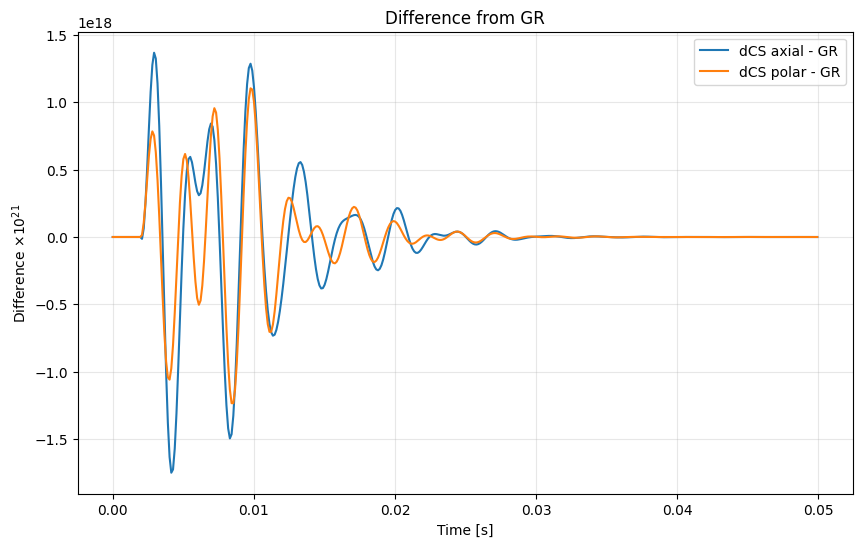

In [5]:
plt.figure()
plt.plot(times, 1e21 * (signal_dcs_axial.h_plus - signal_gr_exact_modes.h_plus), label="dCS axial - GR")
plt.plot(times, 1e21 * (signal_dcs_polar.h_plus - signal_gr_exact_modes.h_plus), label="dCS polar - GR")
plt.xlabel("Time [s]")
plt.ylabel(r"Difference $\times 10^{21}$")
plt.title("Difference from GR")
plt.legend()
plt.show()


GR exact-mode template
----------------------
max |h|: 1.318521365603592
max |h_plus|: 1.314053575615947
max |h_cross|: 1.079165442459034

Scalar-tensor total template
----------------------------
max |h|: 1.4309622821344972
max |h_plus|: 1.425221367859783
max |h_cross|: 1.180676427627861

Scalar-tensor tensor-only piece
-------------------------------
max |h|: 1.3193313606180286
max |h_plus|: 1.3147892234671676
max |h_cross|: 1.086200558034742

Scalar-tensor scalar-only piece
-------------------------------
max |h|: 0.11199900569746023
max |h_plus|: 0.11043214439261534
max |h_cross|: 0.09504569346693255


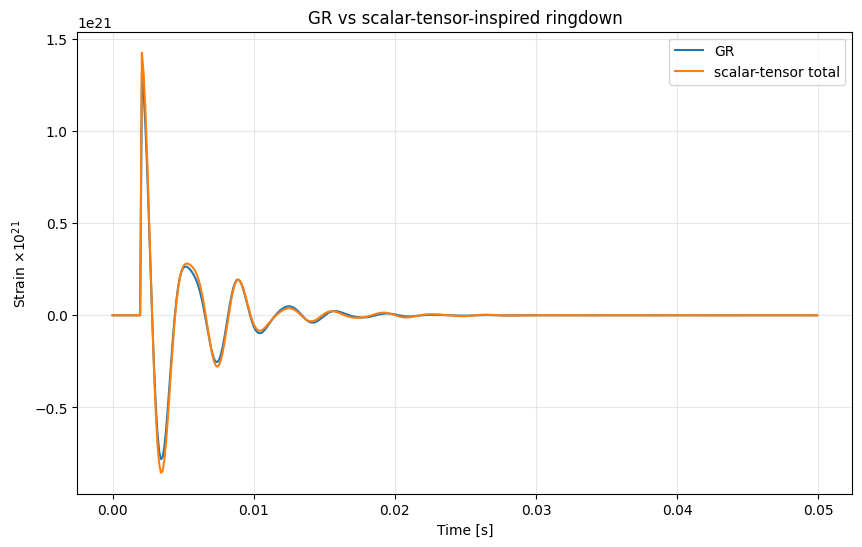

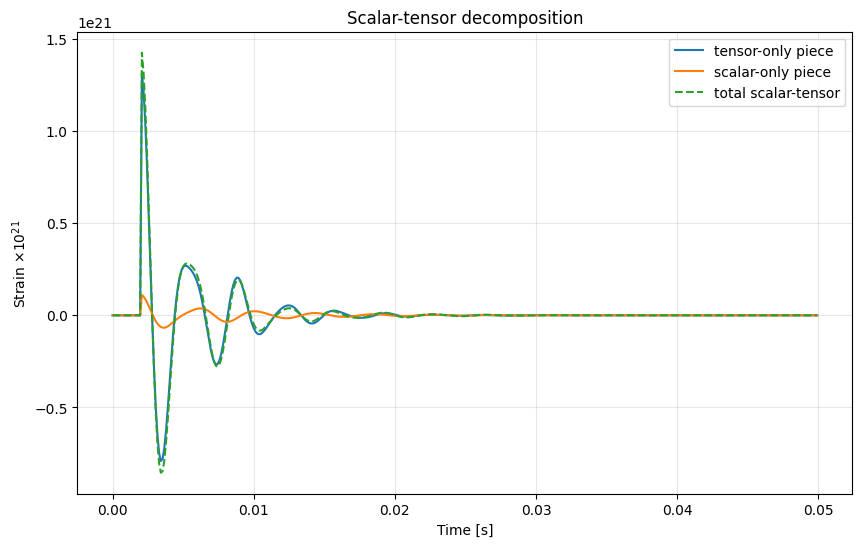

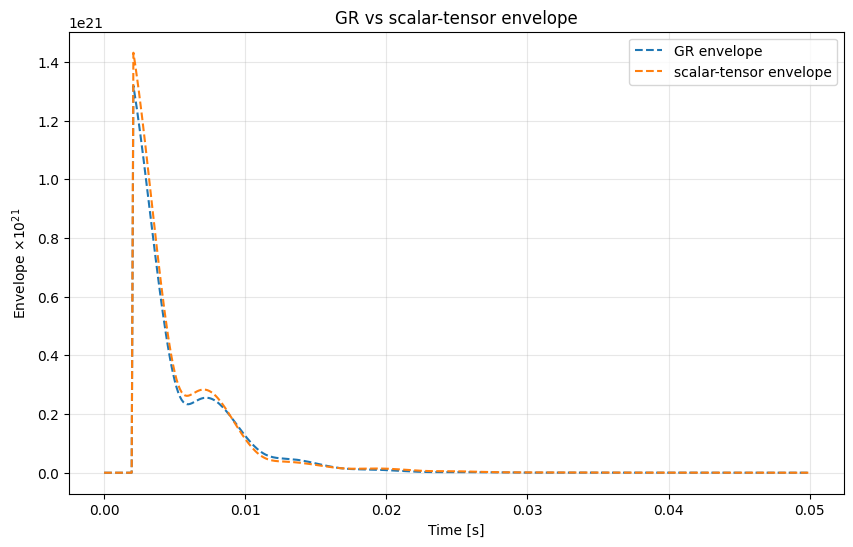

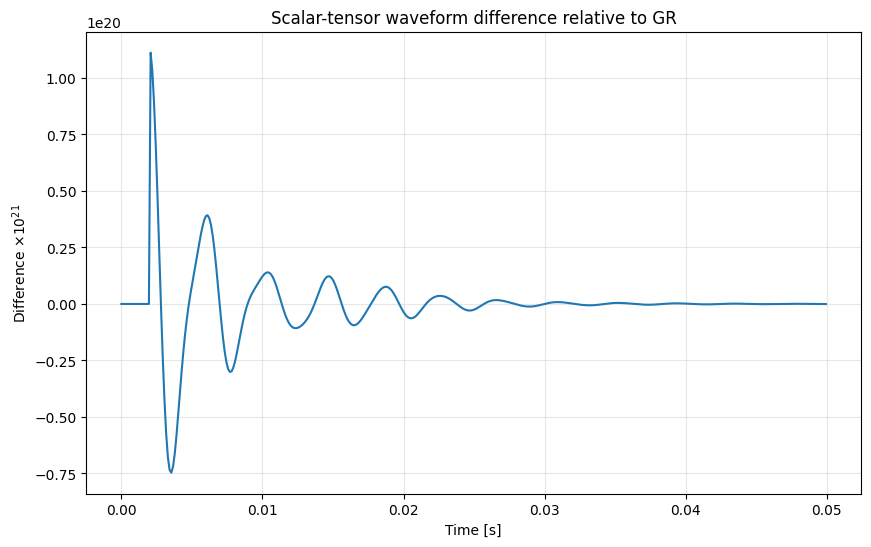


Scalar-tensor vs GR diagnostics
-------------------------------
Overlap(GR, scalar-tensor)  = 0.999032
Mismatch(GR, scalar-tensor) = 0.000968

Scalar-led mode summary
-----------------------
scalar_fundamental: A=0.0800, phase=0.1500, f=240.00 Hz, tau=6.500 ms
scalar_secondary: A=0.0350, phase=-0.2500, f=410.00 Hz, tau=3.000 ms


In [6]:


scalar_tensor_tensor_shifts_exactish = {
    (2, 2, 0): {
        "d_omega_frac": 0.004,
        "d_tau_frac":   0.025,
        "d_amp_frac":   0.000,
        "d_phase":      0.000,
    },
    (3, 3, 0): {
        "d_omega_frac": 0.006,
        "d_tau_frac":   0.040,
        "d_amp_frac":   0.000,
        "d_phase":      0.000,
    },
    (3, 2, 0): {
        "d_omega_frac": 0.003,
        "d_tau_frac":   0.030,
        "d_amp_frac":   0.000,
        "d_phase":      0.000,
    },
}

scalar_led_modes_exactish = [
    ScalarLedMode(
        label="scalar_fundamental",
        amplitude=0.08,
        phase=0.15,
        f_hz=240.0,
        tau_s=0.0065,
    ),
    ScalarLedMode(
        label="scalar_secondary",
        amplitude=0.035,
        phase=-0.25,
        f_hz=410.0,
        tau_s=0.0030,
    ),
]

st_params_exactish = ScalarTensorParameters(
    tensor_mode_shifts=scalar_tensor_tensor_shifts_exactish,
    scalar_modes=scalar_led_modes_exactish,
    scalar_to_tensor_projection=1.0,
)

signal_st_exactish = generate_scalar_tensor_ringdown(
    remnant=remnant,
    modes=modes_dcs_exact,
    st_params=st_params_exactish,
    t=times,
    t0=t0,
)

signal_gr_exact_modes = generate_gr_ringdown(
    remnant=remnant,
    modes=modes_dcs_exact,
    t=times,
    t0=t0,
)

st_tensor_only_params = ScalarTensorParameters(
    tensor_mode_shifts=scalar_tensor_tensor_shifts_exactish,
    scalar_modes=[],
    scalar_to_tensor_projection=1.0,
)

st_scalar_only_params = ScalarTensorParameters(
    tensor_mode_shifts={},
    scalar_modes=scalar_led_modes_exactish,
    scalar_to_tensor_projection=1.0,
)

signal_st_tensor_only = generate_scalar_tensor_ringdown(
    remnant=remnant,
    modes=modes_dcs_exact,
    st_params=st_tensor_only_params,
    t=times,
    t0=t0,
)

signal_st_scalar_only = generate_scalar_tensor_ringdown(
    remnant=remnant,
    modes=[],
    st_params=st_scalar_only_params,
    t=times,
    t0=t0,
)

def summarize_signal(name: str, sig: RingdownSignal):
    env = np.abs(sig.h_complex)
    print(f"\n{name}")
    print("-" * len(name))
    print("max |h|:", np.max(env))
    print("max |h_plus|:", np.max(np.abs(sig.h_plus)))
    print("max |h_cross|:", np.max(np.abs(sig.h_cross)))

summarize_signal("GR exact-mode template", signal_gr_exact_modes)
summarize_signal("Scalar-tensor total template", signal_st_exactish)
summarize_signal("Scalar-tensor tensor-only piece", signal_st_tensor_only)
summarize_signal("Scalar-tensor scalar-only piece", signal_st_scalar_only)

scale = 1e21

plt.figure()
plt.plot(times, scale * signal_gr_exact_modes.h_plus, label="GR")
plt.plot(times, scale * signal_st_exactish.h_plus, label="scalar-tensor total")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("GR vs scalar-tensor-inspired ringdown")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, scale * signal_st_tensor_only.h_plus, label="tensor-only piece")
plt.plot(times, scale * signal_st_scalar_only.h_plus, label="scalar-only piece")
plt.plot(times, scale * signal_st_exactish.h_plus, "--", label="total scalar-tensor")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("Scalar-tensor decomposition")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, scale * np.abs(signal_gr_exact_modes.h_complex), "--", label="GR envelope")
plt.plot(times, scale * np.abs(signal_st_exactish.h_complex), "--", label="scalar-tensor envelope")
plt.xlabel("Time [s]")
plt.ylabel(r"Envelope $\times 10^{21}$")
plt.title("GR vs scalar-tensor envelope")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, scale * (signal_st_exactish.h_plus - signal_gr_exact_modes.h_plus))
plt.xlabel("Time [s]")
plt.ylabel(r"Difference $\times 10^{21}$")
plt.title("Scalar-tensor waveform difference relative to GR")
plt.show()

def waveform_inner_product(h1: np.ndarray, h2: np.ndarray, dt: float) -> float:
    return float(np.sum(h1 * h2) * dt)

def waveform_norm(h: np.ndarray, dt: float) -> float:
    return np.sqrt(max(waveform_inner_product(h, h, dt), 0.0))

def waveform_overlap(h1: np.ndarray, h2: np.ndarray, dt: float) -> float:
    n1 = waveform_norm(h1, dt)
    n2 = waveform_norm(h2, dt)
    if n1 == 0.0 or n2 == 0.0:
        return 0.0
    return waveform_inner_product(h1, h2, dt) / (n1 * n2)

def waveform_mismatch(h1: np.ndarray, h2: np.ndarray, dt: float) -> float:
    return 1.0 - waveform_overlap(h1, h2, dt)

ov_st = waveform_overlap(signal_gr_exact_modes.h_plus, signal_st_exactish.h_plus, dt)
mm_st = waveform_mismatch(signal_gr_exact_modes.h_plus, signal_st_exactish.h_plus, dt)

print("\nScalar-tensor vs GR diagnostics")
print("-------------------------------")
print(f"Overlap(GR, scalar-tensor)  = {ov_st:.6f}")
print(f"Mismatch(GR, scalar-tensor) = {mm_st:.6f}")

print("\nScalar-led mode summary")
print("-----------------------")
for sm in scalar_led_modes_exactish:
    print(
        f"{sm.label}: "
        f"A={sm.amplitude:.4f}, "
        f"phase={sm.phase:.4f}, "
        f"f={sm.f_hz:.2f} Hz, "
        f"tau={1e3*sm.tau_s:.3f} ms"
    )